# Homework 2: DataFrames, Data Visualization, and Functions

## Due Saturday, October 18th at 11:59PM

Welcome to Homework 2! This week, we will cover DataFrame manipulations, making visualizations, and defining functions. You can find additional help on these topics in  [BPD 6, 9-12](https://notes.dsc10.com/01-getting_started/functions-defining.html) in the `babypandas` notes and [CIT 7-7.3](https://inferentialthinking.com/chapters/07/Visualization.html) in the textbook.

### Instructions

Remember to start early and submit often. You are given six slip days throughout the quarter to extend deadlines. See the syllabus for more details. With the exception of using slip days, late work will not be accepted unless you have made special arrangements with your instructor.

**Important**: For homeworks, the `otter` tests don't usually tell you that your answer is correct. More often, they help catch careless mistakes. It's up to you to ensure that your answer is correct. If you're not sure, ask someone (not for the answer, but for some guidance about your approach). These are great questions for office hours (see the schedule on the [Calendar](https://dsc10.com/calendar)) or Campuswire. Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. 

**Please do not use for-loops for any questions in this homework.** If you don't know what a for-loop is, don't worry – we haven't covered them yet. But if you do know what they are and are wondering why it's not OK to use them, it is because loops in Python are slow, and looping over arrays and DataFrames should usually be avoided.

<font color=red>**🚨 If you create a data visualization that is too cluttered to read or takes more than a few seconds to generate, this is a sign you are doing something wrong. Do not submit code like this, or the Gradescope autograder may fail to grade your entire assignment. It's better to leave a question blank than to submit code that will cause the autograder to fail on your full assignment.**</font>

In [1]:
# Please don't change this cell, but do make sure to run it
import babypandas as bpd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('seaborn-colorblind')
plt.rcParams['figure.figsize'] = (10, 5)

import otter
grader = otter.Notebook()

## 1. Gotta Catch 'Em All! ✅

<center><img src="./images/pokemon.png" width=400/></center>

Pokémon is an immensely popular video game and animation franchise that originated in Japan in 1996. Pokémon, short for Pocket Monsters, come in a variety of types.  In this problem, we will investigate how attack and defense statistics vary among these types.

The file named `pokedex.csv` in the `data/` directory ([source](https://www.kaggle.com/datasets/cristobalmitchell/pokedex)) has a row for each Pokémon, and the following columns.

|Column|Description|
|------|-----------|
|`'pokedex_number'`|The Pokémon's identification number in an encyclopedia of all Pokémon.|
|`'name'`|The name of the Pokémon.|
|`'type'`|The categorical type of the Pokémon, for example, "normal", "fire", "water". Each Pokémon is limited to one primary type for simplicity.|
|`'hp'`| Hit points. Indicates how much damage a Pokémon can tolerate.|
|`'attack'`|The Pokémon's power for physical moves.|
|`'defense'`|The Pokémon's ability to prevent damage from attacks.|
|`'sp_attack'`|Special attack. The Pokémon's power for special offensive moves.|
|`'sp_defense'`|Special defense. The Pokémon's ability to prevent damage from special attacks.|
|`'is_legendary'`|Indicates whether the Pokémon is legendary. Legendary Pokémon are rare and powerful. 1 means legendary, 0 means not.|
|`'generation'`|A group of Pokémon that are compatible for Pokémon games. Ranges from 1 to 8.|

First, we read the data in as a DataFrame.

In [2]:
pokedex = bpd.read_csv('data/pokedex.csv')
pokedex

,pokedex_number,name,type,hp,attack,defense,sp_attack,sp_defense,is_legendary,generation
0,460,Abomasnow,grass,90,92,75,92,85,0,4
1,63,Abra,psychic,25,20,15,105,55,0,1
2,359,Absol,dark,65,130,60,75,60,0,3
3,617,Accelgor,bug,80,70,40,100,60,0,5
4,681,Aegislash,steel,60,50,140,50,140,0,6
...,...,...,...,...,...,...,...,...,...,...
893,571,Zoroark,dark,60,105,60,120,60,0,5
894,570,Zorua,dark,40,65,40,80,40,0,5
895,41,Zubat,poison,40,45,35,30,40,0,1
896,634,Zweilous,dark,72,85,70,65,70,0,5


Let's explore particular columns to get to know the data a little better. The `.describe()` method gives us some useful information about a column. Try it out on the `'name'` column.

In [3]:
pokedex.get('name').describe()

count           898
unique          898
top       Abomasnow
freq              1
Name: name, dtype: object

We learn that this column has 898 values, all of which are unique, and as a result the most frequent name appears only once.

If we use this same method on the `'type'` column, we'll see that although there are 898 entries, only 18 of them are unique. There are many Pokémon with the same `'type'`. The most common `'type'` is `'water'`; there are 123 such Pokémon. 

In [4]:
pokedex.get('type').describe()

count       898
unique       18
top       water
freq        123
Name: type, dtype: object

**Question 1.1.** Which would be a better choice of index for this dataset, `'name'` or `'type'`? Set the index of `pokedex` to whichever of these two attributes makes more sense.

In [5]:
pokedex = pokedex.set_index('name')
pokedex

,pokedex_number,type,hp,attack,defense,sp_attack,sp_defense,is_legendary,generation
name,,,,,,,,,
Abomasnow,460,grass,90,92,75,92,85,0,4
Abra,63,psychic,25,20,15,105,55,0,1
Absol,359,dark,65,130,60,75,60,0,3
Accelgor,617,bug,80,70,40,100,60,0,5
Aegislash,681,steel,60,50,140,50,140,0,6
...,...,...,...,...,...,...,...,...,...
Zoroark,571,dark,60,105,60,120,60,0,5
Zorua,570,dark,40,65,40,80,40,0,5
Zubat,41,poison,40,45,35,30,40,0,1


In [6]:
grader.check("q1_1")

q1_1 results: All test cases passed!

**Question 1.2.** Assign `weakest_attack` and `weakest_defense` to the names of the weakest Pokémon in terms of attack and defense respectively.

Similarly, assign `strongest_attack` and `strongest_defense` to the names of the strongest Pokémon in terms of attack and defense respectively.

In the case of a tie, choose any one of the equally weakest or equally strongest Pokémon.

In [7]:
weakest_attack = pokedex.sort_values('attack', ascending = True).index[0]
print('Weakest attack:', weakest_attack)

strongest_attack = pokedex.sort_values('attack', ascending = False).index[0]
print('Strongest attack:', strongest_attack)

weakest_defense = pokedex.sort_values('defense', ascending = True).index[0]
print('Weakest defense:', weakest_defense)

strongest_defense = pokedex.sort_values('defense', ascending = False).index[0]
print('Strongest defense:', strongest_defense)

Weakest attack: Happiny
Strongest attack: Kartana
Weakest defense: Chansey
Strongest defense: Shuckle


In [8]:
grader.check("q1_2")

q1_2 results: All test cases passed!

**Question 1.3.** Typically at the beginning of a game, the Pokémon trainer (the player) has to make a choice between `'water'`, `'grass'`, and `'fire'` Pokémon. Make a DataFrame named `water_grass_fire` containing only Pokémon of these `'type'`s. All columns of `pokedex` should be included.

In [9]:
water_grass_fire = pokedex[(pokedex.get('type') == 'water')|(pokedex.get('type') == 'grass')|(pokedex.get('type') == 'fire')]
water_grass_fire

,pokedex_number,type,hp,attack,defense,sp_attack,sp_defense,is_legendary,generation
name,,,,,,,,,
Abomasnow,460,grass,90,92,75,92,85,0,4
Alomomola,594,water,165,75,80,40,45,0,5
Amoonguss,591,grass,114,85,70,85,80,0,5
Appletun,842,grass,110,85,80,100,80,0,8
Applin,840,grass,40,40,80,40,40,0,8
...,...,...,...,...,...,...,...,...,...
Whimsicott,547,grass,60,67,85,77,75,0,5
Whiscash,340,water,110,78,73,76,71,0,3
Wingull,278,water,40,30,30,55,30,0,3


In [10]:
grader.check("q1_3")

q1_3 results: All test cases passed!

**Question 1.4.** Some Pokémon are considered *legendary*, which means they are especially rare or powerful. The column `'is_legendary'` records this information in our data set. 

Create a DataFrame named `legendary_pokemon`, indexed by `'type'` and having one column, called `'num_legendary'`, that contains the number of legendary Pokémon of each `'type'`. Only include `'type'`s with at least one legendary Pokémon of that `'type'`.

***Hint:*** You will need to [drop and rename columns](https://dsc10.com/resources/lectures/lec06/lec06.html#Adjusting-columns-with-.assign,-.drop,-and-.get). Instead of using `.drop`, you may want to use `.get` [with a list](https://dsc10.com/resources/lectures/lec06/lec06.html#Two-ways-to-.get) containing the name of a single column.

In [11]:
le_pokemon = pokedex.get(['type', 'is_legendary'])[pokedex.get('is_legendary') != 0].groupby('type').count()
legendary_pokemon = le_pokemon.assign(num_legendary = le_pokemon.get('is_legendary'))
legendary_pokemon = legendary_pokemon.drop(columns = 'is_legendary')
legendary_pokemon

,num_legendary
type,
dark,1
dragon,5
fairy,1
fire,1
ghost,1
ground,1
psychic,7
steel,1
water,2


In [12]:
grader.check("q1_4")

q1_4 results: All test cases passed!

**Question 1.5.** Notice that the `legendary_pokemon` DataFrame has fewer than 18 rows, though the original data had 18 unique `'type'`s; this means that there are certain `'type'`s that don't have any legendary Pokémon. Determine which `'type'`s don't have any legendary Pokémon, and assign `non_legendary` to an array of these `'type'`s. 

***Hint:*** You will want to group the Pokémon by `'type'`. What aggregation method could you use to identify when there are no legendary Pokémon of a given type?

In [13]:
# non_legendary = pokedex.groupby(['type', 'is_legendary']).count()
# non_legendary
non = pokedex.groupby('type').mean()
non_legendary = np.array(non[non.get('is_legendary') == 0].reset_index().get('type'))

non_legendary

array(['bug', 'electric', 'fighting', 'flying', 'grass', 'ice', 'normal',
       'poison', 'rock'], dtype=object)

In [14]:
grader.check("q1_5")

q1_5 results: All test cases passed!

**Question 1.6.** Suppose that as a Pokémon trainer, you want to assemble a strong team of Pokémon of various `'type'`s. Create a DataFrame called `mean_stats`, indexed by `'type'`, that contains the average statistics for Pokémon of each type. `mean_stats` should have five columns: `'hp'`, `'attack'`, `'defense'`, `'sp_attack'`, and `'sp_defense'`.

In [15]:
mean_stats = pokedex.groupby('type').mean().drop(columns = ['pokedex_number', 'is_legendary', 'generation'])
mean_stats

,hp,attack,defense,sp_attack,sp_defense
type,,,,,
bug,56.253333,66.253333,69.346667,56.720000,62.880000
dark,72.694444,84.361111,66.305556,71.111111,67.583333
dragon,78.451613,98.806452,76.903226,80.290323,78.000000
electric,62.387755,73.897959,61.612245,84.285714,67.244898
fairy,72.047619,63.238095,68.428571,78.904762,87.952381
...,...,...,...,...,...
poison,67.971429,73.028571,70.742857,66.142857,66.628571
psychic,72.103448,63.534483,67.948276,91.137931,83.586207
rock,67.120000,87.120000,98.960000,59.740000,73.260000


In [16]:
grader.check("q1_6")

q1_6 results: All test cases passed!

**Question 1.7.** A strong Pokémon is one that has high values for `'hp'`, `'attack'`, `'defense'`, `'sp_attack'`, and `'sp_defense'`. Suppose that you develop a formula to summarize all of these stats into a single number called strength. The strength of a Pokémon is a weighted average of these five stats, where each stat is weighted as follows:

- `hp`: 30%
- `attack`: 20%
- `defense`: 20%
- `sp_attack`: 15%
- `sp_defense`: 15%

Define a function called `calculate_strength` that takes as input the `'pokedex_number'` of a Pokémon and returns its strength, as defined above.

In [17]:
def calculate_strength(number):
    poke = pokedex.set_index('pokedex_number').loc[number]
    return poke.get('hp') * 0.3 + poke.get('attack') * 0.2 + poke.get('defense') * 0.2 + poke.get('sp_attack') * 0.15 + poke.get('sp_defense') * 0.15

In [18]:
grader.check("q1_7")

q1_7 results: All test cases passed!

**Question 1.8.** Create a DataFrame called `with_strength` that contains all the columns of `pokedex` plus one more called `'strength'`, containing the strength of each Pokémon as defined in the previous question. Order the rows in descending order of `'strength'`.

In [19]:
with_strength = pokedex.assign(strength = pokedex.get('pokedex_number').apply(calculate_strength)).sort_values(by = 'strength', ascending = False)
with_strength

,pokedex_number,type,hp,attack,defense,sp_attack,sp_defense,is_legendary,generation,strength
name,,,,,,,,,,
Giratina,487,ghost,150,100,120,100,120,1,4,122.00
Slaking,289,normal,150,160,100,95,65,0,3,121.00
Solgaleo,791,psychic,137,137,107,113,89,1,7,120.20
Guzzlord,799,dark,223,101,53,97,53,0,7,120.20
Arceus,493,normal,120,120,120,120,120,0,4,120.00
...,...,...,...,...,...,...,...,...,...,...
Wishiwashi,746,water,45,20,20,25,25,0,7,29.00
Pichu,172,electric,20,40,15,35,35,0,2,27.50
Blipbug,824,bug,25,20,20,25,45,0,8,26.00


In [20]:
grader.check("q1_8")

q1_8 results: All test cases passed!

**Question 1.9.** Considering that Pokémon `generation`s were developed in order, we might wonder how Pokémon have evolved over time. Draw a line plot that shows the trend, across generations, of the median strength of Pokémon from each generation. This kind of plot might help you answer the question "*Are later-generation Pokémon stronger than earlier-generation Pokémon?*"

***Hint:*** You'll have to do some DataFrame manipulation before you can create the line plot.

<!-- BEGIN QUESTION -->

<!--
BEGIN QUESTION
name: q1_9
manual: true
-->

<AxesSubplot:xlabel='generation'>

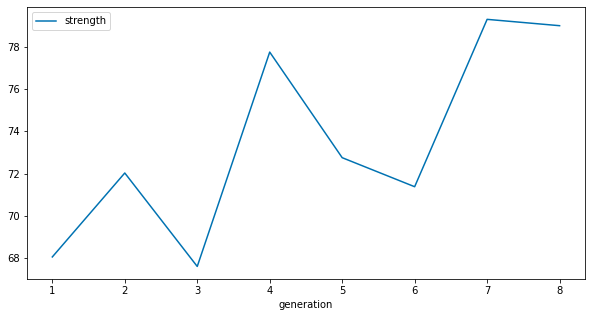

In [21]:
# Create your line plot here.
generation = with_strength.groupby('generation').median()
generation.plot(kind = 'line', y = 'strength')

<!-- END QUESTION -->



## 2. As Seen on TV 📺

In this section, we'll work with a dataset from [Kaggle](https://www.kaggle.com/datasets/devanshiipatel/imdb-tv-shows/)  containing information about different TV shows, originally obtained from the Internet Movie Database (IMDb). In the cell below, we load the dataset in as a DataFrame named `tv_shows`. Take some time to look at the data in `tv_shows` to see what information is recorded.

In [22]:
# Run this cell to load the dataset.
tv_shows = bpd.read_csv('data/tv_shows.csv')
tv_shows

,Title,About,Genres,Actors,Rating,Votes,Years
0,The Family Man,A working man from the National Investigation ...,"Action, Comedy, Drama","Manoj Bajpayee, Samantha Akkineni, Priyamani, ...",8.8,57632,2019–
1,Lucifer,Lucifer Morningstar has decided he's had enoug...,"Crime, Drama, Fantasy","Tom Ellis, Lauren German, Lesley-Ann Brandt, K...",8.1,252826,2016–
2,The Handmaid's Tale,"Set in a dystopian future, a woman is forced t...","Drama, Sci-Fi, Thriller","Elisabeth Moss, Yvonne Strahovski, Joseph Fien...",8.4,187007,2017–
3,StartUp,"A desperate banker, a Haitian-American gang lo...","Crime, Thriller","Adam Brody, Edi Gathegi, Otmara Marrero, Krist...",8.0,18165,2016–2018
4,Game of Thrones,Nine noble families fight for control over the...,"Action, Adventure, Drama","Emilia Clarke, Peter Dinklage, Kit Harington, ...",9.3,1823966,2011–2019
...,...,...,...,...,...,...,...
2826,A Drop of True Blood,A kids' show centered around a special agent-i...,"Short, Drama, Fantasy","Claudia Abrego, Ryan Kwanten, Stephen Moyer, A...",8.1,572,2010–
2827,Yu-Gi-Oh! GX,An anthology series in which each episode is a...,"Animation, Action, Adventure","Matthew Labyorteaux, Wayne Grayson, Tony Saler...",6.8,4115,2004–2008
2828,Special Agent Oso,Four teenage heroes-for-hire warp through the ...,"Animation, Action, Adventure","Meghan Strange, Gary Anthony Williams, Sean As...",5.2,475,2009–2012
2829,Metal Hurlant Chronicles,An expose on the U.S. government's secret prog...,"Action, Sci-Fi","Scott Adkins, Karl E. Landler, Dominique Pinon...",5.8,1630,2012–2014


**Question 2.1.** If you look at the `'Years'` column in the DataFrame, you'll notice that most of the year ranges are separated by en dashes (`–`). Note that if a show was still on air at the time of data collection, its value in the `'Years'` column will end with an en dash. For example, in the first row of the DataFrame, the value in the `'Years'` column is `'2019–'`, meaning that the show has been airing since 2019. The presence of en dashes indicates that the `'Years'` column contains strings, not ints, since Python never displays ints separated by en dashes.

Complete the implementation of the function `extract_start_year_as_int`, which takes as input a string `v` representing a year range, like the values listed in the DataFrame above, and outputs the start year of `v` as an int. For example, passing in the string `'2016–2018'` to the function should return the int `2016`.

Then, use your function to add a column called `'StartYear'` to the `tv_shows` DataFrame that contains the start year of each show as an integer. Make sure to "save" your changes in the `tv_shows` DataFrame!


**_Hints:_** 
- En dashes (`–`) are **not** the same as hyphens (`-`)! The easiest way to get an en dash is to **copy it from here**: `–`.
- The string method [`.split()`](https://docs.python.org/3/library/stdtypes.html#str.split) will be helpful.


In [23]:
def extract_start_year_as_int(v):
    return int(v.split('–')[0])

In [24]:

tv_shows = tv_shows.assign(StartYear = tv_shows.get('Years').apply(extract_start_year_as_int))
tv_shows

,Title,About,Genres,Actors,Rating,Votes,Years,StartYear
0,The Family Man,A working man from the National Investigation ...,"Action, Comedy, Drama","Manoj Bajpayee, Samantha Akkineni, Priyamani, ...",8.8,57632,2019–,2019
1,Lucifer,Lucifer Morningstar has decided he's had enoug...,"Crime, Drama, Fantasy","Tom Ellis, Lauren German, Lesley-Ann Brandt, K...",8.1,252826,2016–,2016
2,The Handmaid's Tale,"Set in a dystopian future, a woman is forced t...","Drama, Sci-Fi, Thriller","Elisabeth Moss, Yvonne Strahovski, Joseph Fien...",8.4,187007,2017–,2017
3,StartUp,"A desperate banker, a Haitian-American gang lo...","Crime, Thriller","Adam Brody, Edi Gathegi, Otmara Marrero, Krist...",8.0,18165,2016–2018,2016
4,Game of Thrones,Nine noble families fight for control over the...,"Action, Adventure, Drama","Emilia Clarke, Peter Dinklage, Kit Harington, ...",9.3,1823966,2011–2019,2011
...,...,...,...,...,...,...,...,...
2826,A Drop of True Blood,A kids' show centered around a special agent-i...,"Short, Drama, Fantasy","Claudia Abrego, Ryan Kwanten, Stephen Moyer, A...",8.1,572,2010–,2010
2827,Yu-Gi-Oh! GX,An anthology series in which each episode is a...,"Animation, Action, Adventure","Matthew Labyorteaux, Wayne Grayson, Tony Saler...",6.8,4115,2004–2008,2004
2828,Special Agent Oso,Four teenage heroes-for-hire warp through the ...,"Animation, Action, Adventure","Meghan Strange, Gary Anthony Williams, Sean As...",5.2,475,2009–2012,2009
2829,Metal Hurlant Chronicles,An expose on the U.S. government's secret prog...,"Action, Sci-Fi","Scott Adkins, Karl E. Landler, Dominique Pinon...",5.8,1630,2012–2014,2012


In [25]:
grader.check("q2_1")

q2_1 results: All test cases passed!

**Question 2.2.** You've been starting to feel that TV shows are just not as good as they used to be.  Create an appropriate plot that shows the relationship between the `'StartYear'` and the `'Rating'` of each show in `tv_shows`.

<AxesSubplot:xlabel='StartYear'>

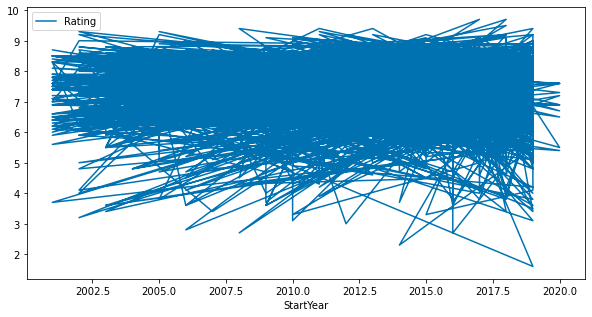

In [26]:
# Create your plot here.
tv_shows.plot(kind = 'line', x = 'StartYear', y='Rating')

Unfortunately, this plot is not very informative. Instead, make a plot that shows how the **median** `'Rating'` of all shows from a given `'StartYear'` has changed over time. 

<AxesSubplot:xlabel='StartYear'>

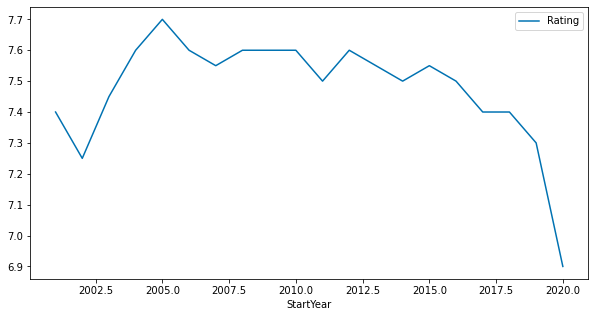

In [27]:
# Create your plot here.
tv_shows.groupby('StartYear').median().plot(kind = 'line', y = 'Rating')


Now, use the second plot you made to determine whether TV shows are as good as they used to be. Choose the most accurate statement below and assign an integer from 1 to 3 to the variable `q2_2`.

1. TV shows have been getting worse since 2000.
2. TV shows were getting worse until 2005, and since then, they have improved.
3. TV shows have been getting worse since 2005.

In [28]:
q2_2 = 3
q2_2

3

In [29]:
grader.check("q2_2")

q2_2 results: All test cases passed!

**Question 2.3.** Assign `most_common_genres` to a DataFrame that contains the five most common genre combinations of TV shows in our dataset, in descending order of popularity. The DataFrame should be indexed by `'Genres'` and have only one column, `'Count'`, which is the number of TV shows of that genre combination.

**_Note:_**  For this question, each TV show is assicated with one set of genres, which determines its genre combination. For example, `'Action, Adventure, Drama'` is one genre combination. `'Drama'`, by itself, is another genre combination.

In [30]:
top5genres = tv_shows.get(['Genres', 'Title']).groupby('Genres').count().sort_values('Title', ascending = False).iloc[0:5]
most_common_genres = top5genres.assign(Count = top5genres.get('Title')).drop(columns = 'Title')
most_common_genres

,Count
Genres,
Comedy,270
Drama,180
"Crime, Drama, Mystery",173
"Animation, Action, Adventure",142
"Comedy, Drama",107


In [31]:
grader.check("q2_3")

q2_3 results: All test cases passed!

**Question 2.4.** Using the `most_common_genres` DataFrame you created in Question 2.3, create a horizontal bar chart that shows the distribution of TV shows into these five genre combinations. Make sure the bars are sorted such that the most common genre appears as the top-most bar in the bar chart.

<!-- BEGIN QUESTION -->

<!--
BEGIN QUESTION
name: q2_4
manual: true
-->

<AxesSubplot:ylabel='Genres'>

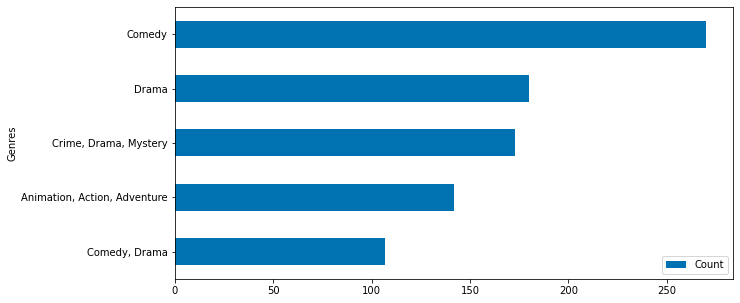

In [32]:
# Create your bar chart here.
most_common_genres.sort_values('Count', ascending = True).plot(kind = 'barh')

<!-- END QUESTION -->



**Question 2.5.** Assign the variable `third_highest` to the genre combination with the third highest average overall `'Rating'` (*not* the third highest frequency), among all genre combinations in `tv_shows`.

Do not manually type out your answer. Use `babypandas` methods to produce the answer.

In [33]:
third_highest = tv_shows.groupby('Genres').mean().sort_values('Rating', ascending = False).index[2]
third_highest

'Adventure, Comedy, Mystery'

In [34]:
grader.check("q2_5")

q2_5 results: All test cases passed!

**Question 2.6.** Create a histogram showing the distribution of `'Rating'` among shows in the `tv_shows` DataFrame.

Remember to set `density=True` since we always use density histograms and `ec='w'` to make the separation of the bars more clear. You don't have to set the `bins` argument.

<!-- BEGIN QUESTION -->

<!--
BEGIN QUESTION
name: q2_6
manual: true
-->

<AxesSubplot:ylabel='Frequency'>

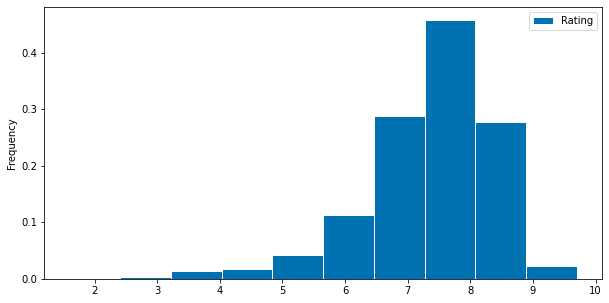

In [35]:
# Create your histogram here.
tv_shows.plot(kind = 'hist', y = 'Rating', density = True, ec = 'w')

<!-- END QUESTION -->

**Question 2.7.** Using the `'StartYear'` column, identify the year between 2001 and 2009 (inclusive) that has the lowest total number of `'Votes'` for TV shows released that year. Assign this year to the variable `lowest_01_09`.

Please make sure to use `babypandas` methods to find your answer; you should not type in the year manually.

<!--
BEGIN QUESTION
name: q2_7
-->

In [36]:
lowest_01_09 = tv_shows[(tv_shows.get('StartYear') <= 2009) & (tv_shows.get('StartYear') >= 2001)].groupby('StartYear').min().get(['Votes']).sort_values('Votes', ascending = True).index[0]
lowest_01_09

2009

In [37]:
grader.check("q2_7")

q2_7 results: All test cases passed!

## 3. The Best Invention of the 20th Century 🍜

Instant ramen was first invented by Momofuku Ando in 1958 to cure hunger during wartime. It started off with only one kind for its original purpose, but the instant ramen industry has expanded over the years, and now there are over 100 different kinds of instant ramen. At the turn of the millenium, 2000 Japanese citizens even [ranked](https://abcnews.go.com/International/story?id=81946&page=1) instant ramen as the best invention of the 20th century! Click [here](https://www.cupnoodles-museum.jp/en/osaka_ikeda/) to learn more about the history of this quintessential college meal.

<img src="./images/noodles-lowres-8607.png" width=350/>

We have a [dataset of instant ramen ratings from Kaggle](https://www.kaggle.com/datasets/residentmario/ramen-ratings?resource=download). First, we'll read in the data from a CSV. There is no good index, so we will leave it unset.

In [38]:
ramen_data = bpd.read_csv('data/ramen-rating.csv')
ramen_data

,Brand,Variety,Style,Country,Stars
0,New Touch,T's Restaurant Tantanmen,Cup,JP,3.75
1,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,TW,1.00
2,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25
3,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,TW,2.75
4,Ching's Secret,Singapore Curry,Pack,IN,3.75
...,...,...,...,...,...
2572,Vifon,"Hu Tiu Nam Vang [""Phnom Penh"" style] Asian Sty...",Bowl,VN,3.50
2573,Wai Wai,Oriental Style Instant Noodles,Pack,TH,1.00
2574,Wai Wai,Tom Yum Shrimp,Pack,TH,2.00
2575,Wai Wai,Tom Yum Chili Flavor,Pack,TH,2.00


Notice that the `'Country'` column contains a country code. We want to convert these country codes into actual country names that everyone can understand.

We'll use a Python [dictionary](https://www.tutorialspoint.com/python/python_dictionary.htm) to help us with this conversion. A dictionary is a simple way to map a unique key to a value. For example, the dictionary below maps course codes to course names.

In [39]:
dsc_courses = {
    # key: value
    'DSC 10': 'Principles of Data Science',
    'DSC 20': 'Programming and Basic Data Structures for Data Science',
    'DSC 30': 'Data Structures and Algorithms for Data Science',
    'DSC 40A': 'Theoretical Foundations of Data Science I',
    'DSC 40B': 'Theoretical Foundations of Data Science II',
    'DSC 80': 'The Practice and Application of Data Science'
}

We can access the value corresponding to each key using bracket notation.

In [40]:
dsc30_name = dsc_courses['DSC 30']
dsc30_name

'Data Structures and Algorithms for Data Science'

Here, `'DSC 30'` is the key and `'Data Structures and Algorithms for Data Science'` is the value.

Let's use a dictionary to help us with our country code to country name conversion. Below is a dictionary containing country codes as keys and country names as values for each of the countries in our ramen dataset.

In [41]:
# Run this cell, DO NOT change it.
country_codes = {
    'AU':'Australia',
    'BD':'Bangladesh', 
    'BR':'Brazil', 
    'KH':'Cambodia' , 
    'CA':'Canada', 
    'CN':'China',
    'CO':'Colombia', 
    'DXB':'Dubai' , 
    'EE':'Estonia' , 
    'FIJI':'Fiji', 
    'FI':'Finland' , 
    'DE':'Germany',
    'GHAN':'Ghana' , 
    'NL':'Holland', 
    'HK':'Hong Kong', 
    'HU':'Hungary', 
    'IN':'India', 
    'ID':'Indonesia',
    'JP':'Japan', 
    'MY':'Malaysia', 
    'MX':'Mexico', 
    'MM':'Myanmar', 
    'NP':'Nepal', 
    'AN':'Netherlands',
    'NG':'Nigeria', 
    'PK':'Pakistan', 
    'PH':'Philippines', 
    'PL':'Poland', 
    'SWK':'Sarawak',
    'SG':'Singapore', 
    'KOR':'South Korea', 
    'SE':'Sweden', 
    'TW':'Taiwan', 
    'TH':'Thailand', 
    'UK' :'United Kingdom' ,
    'USA':'United States', 
    'VN':'Vietnam' 
    }

**Question 3.1.** Using the dictionary `country_codes`, define a function named `code_to_country` that takes as input a country code and returns the corresponding country's name. This should only take one line of code.

_*Hints*_: 
- If you're stuck, take a look at the DSC 30 example above.
- Once you've implemented `code_to_country`, you should verify that it works as intended by trying a few examples yourself. The provided tests will **not** do this for you.

In [42]:
def code_to_country(code):
    return country_codes[code]

In [43]:
grader.check("q3_1")

q3_1 results: All test cases passed!

**Question 3.2.** Use your `code_to_country` function and the `.apply` method to convert all of the country codes in the `'Country'` column of `ramen_data` into country names. Do this without creating an additional column or reordering the existing columns. Assign the resulting DataFrame to the variable name `ramen`.

***Hint:*** `.assign` can be used to replace values in a column, if the column name used corresponds to a column that already exists in the DataFrame.

In [44]:
ramen = ramen_data.assign(Country = ramen_data.get('Country').apply(code_to_country))
ramen

,Brand,Variety,Style,Country,Stars
0,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75
1,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1.00
2,Nissin,Cup Noodles Chicken Vegetable,Cup,United States,2.25
3,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75
4,Ching's Secret,Singapore Curry,Pack,India,3.75
...,...,...,...,...,...
2572,Vifon,"Hu Tiu Nam Vang [""Phnom Penh"" style] Asian Sty...",Bowl,Vietnam,3.50
2573,Wai Wai,Oriental Style Instant Noodles,Pack,Thailand,1.00
2574,Wai Wai,Tom Yum Shrimp,Pack,Thailand,2.00
2575,Wai Wai,Tom Yum Chili Flavor,Pack,Thailand,2.00


In [45]:
grader.check("q3_2")

q3_2 results: All test cases passed!

🚨 **Important**: For the rest of the questions in this section, use the DataFrame `ramen` instead of `ramen_data`.

**Question 3.3.** 
Define a function named `word_count` that returns the number of words in a ramen's `'Variety'`. It should take as input a string from the `'Variety'` column and  return the number of words in that string. We'll consider a piece of text to be a word if and only if it is separated from adjacent words by a space. 
For example:
- `word_count('Cup Noodles Chicken Vegetable')` should return 4.
- `word_count('Tonkotsu-Shoyu Rich Pork Flavor Ramen')` should return 5. Notice that `'Tonkotsu-Shoyu'` counts as one word.

_*Hint*_: The string method [`.split`](https://docs.python.org/3/library/stdtypes.html#str.split) will be helpful.

In [46]:
def word_count(variety):
    return len(variety.split(' '))
    
# Test cases for your own reference. Feel free to test out more!
print(word_count('Cup Noodles Chicken Vegetable'))  # Should print 4
print(word_count('Tonkotsu-Shoyu Rich Pork Flavor Ramen')) # Should print 5

# a = 'Cup Noodles Chicken Vegetable'
# len(a.split(' '))

4
5


In [47]:
grader.check("q3_3")

q3_3 results: All test cases passed!

**Question 3.4.** Create a DataFrame called `with_word_count` with columns from left to right `'Brand'`, `'Country'`, `'Stars'` , `'Style'`, and `'Variety'`and a new column `'Word_Count'` that has the word count for each variety. Sort the DataFrame in descending order of `'Word_Count'`.

_*Note*_: The `'Country'` column should have full country names, not codes.

In [48]:
with_word_count = ramen.assign(Word_Count = ramen.get('Variety').apply(word_count)).sort_values(by = 'Word_Count', ascending=False).get(['Brand', 'Country','Stars' , 'Style', 'Variety', 'Word_Count'])
with_word_count

,Brand,Country,Stars,Style,Variety,Word_Count
1313,ABC,Indonesia,4.25,Cup,Selera Pedas Mi Goreng Cup Rasa Ayam Pedas Lim...,13
475,Roland,United States,0.00,Pack,Ramen Japanese Style Quick-Cooking Alimentary ...,12
199,Nissin,United States,2.50,Cup,Cup Noodles Hot & Spicy Shrimp Flavor Ramen No...,12
1311,ABC,Indonesia,4.00,Cup,Selera Pedas Mi Goreng Cup Rasa Gulai Ayam Ped...,12
652,Nissin,United States,4.00,Bowl,Bowl Noodles Hot & Spicy Chicken Flavor Less S...,12
...,...,...,...,...,...,...
2108,Gefen,United States,3.50,Pack,Chicken,1
1807,Kailo,Hong Kong,3.50,Pack,Chicken,1
1802,JML,China,3.00,Bowl,Seafood,1
2469,Teriyaki Time,United States,2.00,Bowl,Ramen,1


In [49]:
grader.check("q3_4")

q3_4 results: All test cases passed!

**Question 3.5.** Among the ramen that from `'Japan'`, how many words does the longest ramen `'Variety'` have? Assign this number to `most_ramen_words`. How many words does the shortest Japanese ramen `'Variety'` have? Assign this number to `fewest_ramen_words`. What is the absolute difference between these values? Assign this number to `range_ramen_words`.

In [54]:
most_ramen_words = with_word_count.iloc[0].get('Word_Count')
fewest_ramen_words = with_word_count.iloc[-1].get('Word_Count')
range_ramen_words = most_ramen_words - fewest_ramen_words

print('Most ramen words', most_ramen_words)
print('Fewest ramen words:', fewest_ramen_words)
print('Range of ramen words:', range_ramen_words)

Most ramen words 13
Fewest ramen words: 1
Range of ramen words: 12


In [55]:
grader.check("q3_5")

q3_5 results: All test cases passed!

**Question 3.6.** Create a function named `mean_stars` that takes as an input the name of a ramen brand and returns the average `'Stars'` for all ramen belonging to that brand.

In [58]:
def mean_stars(brand):
    return ramen[ramen.get('Brand') == brand].get('Stars').mean()

In [59]:
grader.check("q3_6")

q3_6 results: All test cases passed!

**Question 3.7.** Create a horizontal bar chart that displays the mean word count for all ramen brands that have **more than 10 varieties**. Sort the bars so the brands whose varieties have the most words on average appear at the very top, and those with the fewest words on average appear at the bottom.

_*Hints*_: 
- If you use `.groupby` more than once on the same DataFrame, the order of rows will be the same, even with different aggregation methods, as long as the column you group by is the same.
- To get the bar chart to display nicely, try adjusting the optional `figsize` argument.

<!-- BEGIN QUESTION -->

<!--
BEGIN QUESTION
name: q3_7
manual: true
-->

<AxesSubplot:ylabel='Brand'>

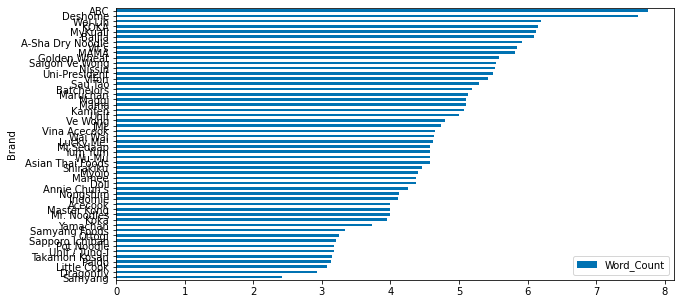

In [72]:
# Create your plot here.
with_word_count.groupby('Brand').mean()[with_word_count.groupby('Brand').count().get('Variety') > 10].sort_values(by='Word_Count').plot(kind = 'barh', y = 'Word_Count')

<!-- END QUESTION -->



**Question 3.8.** Define a function named `point_total` that takes in a full country name and returns a point total for that country's ramen, according to the following scheme:
- 1 point for every variety of ramen that has at least 1 star and less than 3 stars,
- 2 points for every variety with at least 3 stars and less than 4 stars, and
- 3 points for every variety with at least 4 stars (and at most 5 stars, which is the maximum possible).

|Points Received | Stars (Condition)| 
| --- | --- | 
|1| $[1,3)$|
|2| $[3, 4)$ | 
|3| $[4,5]$ |

_*Hint*_: Make sure that your function works for countries that don't have varieties of ramen at every possible number of stars. If you aren't able to accomplish this using grouping, try another strategy! Remember, don't use a for-loop. There is a better solution using DataFrame manipulations.

In [79]:
def point_total(country):
    one_point = with_word_count[
        (with_word_count.get('Country') == country) &
        (with_word_count.get('Stars') >= 1) &
        (with_word_count.get('Stars') < 3)
    ].shape[0]

    two_points = with_word_count[
        (with_word_count.get('Country') == country) &
        (with_word_count.get('Stars') >= 3) &
        (with_word_count.get('Stars') < 4)
    ].shape[0] * 2

    three_points = with_word_count[
        (with_word_count.get('Country') == country) &
        (with_word_count.get('Stars') >= 4) &
        (with_word_count.get('Stars') <= 5)
    ].shape[0] * 3

    return one_point + two_points + three_points

In [80]:
grader.check("q3_8")

q3_8 results: All test cases passed!

**Question 3.9.** Which of the five countries listed below has the **highest** point total, using the points system from Question 3.8? Assign the variable `country` to either 1, 2, 3, 4, or 5 corresponding to your choice.

1. `'Canada'`
1. `'China'`
1. `'Singapore'`
1. `'United States'`
1. `'Vietnam'`



In [77]:
country = 4

In [78]:
grader.check("q3_9")

q3_9 results: All test cases passed!

## 4. Final Stretch 🧘‍♀️

Suppose we have a DataFrame named `data` with two numerical columns, `'x'` and `'y'`. Consider the following scatter plot, which was generated by calling `data.plot(kind='scatter', x='x', y='y')`:

<img src='images/q3_scatter.png' width=400/>

Now consider these two histograms:

<center>
    <table><tr>
        <td><center><b>Histogram A</b><br> <img src='images/q3_hist_one.png' width=400></center> </td>
        <td><center><b>Histogram B</b><br> <img src='images/q3_hist_two.png' width=400></center> </td>
    </tr></table>
</center>

**Question 4.1.** Which of the following lines of code generated Histogram A? Assign either `1`, `2`, `3`, or `4` to `which_code`.

 1. `data.plot(kind='hist', density=False, y='x')`
 2. `data.plot(kind='hist', density=False, y='y')` 
 3. `data.plot(kind='hist', density=True, y='x')`
 4. `data.plot(kind='hist', density=True, y='y')`

In [88]:
which_code = 4

In [89]:
grader.check("q4_1")

q4_1 results: All test cases passed!

**Question 4.2.** Suppose we run this block of code:

```py
new_data = bpd.DataFrame().assign(
    x = data.get('x') / 5,
    y = data.get('y')
)
```
    
We then run 

`new_data.plot(kind='hist', density=True, y='x')`.

How will this histogram look compared to the histogram created by 

`data.plot(kind='hist', density=True, y='x')`, 

assuming both histograms are drawn on the same axes? Assign `histogram_difference` to either 1, 2, 3, or 4, corresponding to your choice.

1. The `new_data` histogram will be wider and taller than the `data` histogram.
2. The `new_data` histogram will be wider and shorter than the `data` histogram.
3. The `new_data` histogram will be narrower and taller than the `data` histogram.
4. The `new_data` histogram will be narrower and shorter than the `data` histogram.

_*Hint*_: Look at the end of [Lecture 7](https://dsc10.com/resources/lectures/lec07/lec07.html#Plotting-overlaid-histograms) for an example of two histograms drawn on the same axes.

In [82]:
histogram_difference = 3

In [83]:
grader.check("q4_2")

q4_2 results: All test cases passed!

**Question 4.3.** Below, we show Histogram B again.

<img src="./images/q3_hist_two.png" width=400/>

What **percent** of values in Histogram B are between -4 (inclusive) and -2 (exclusive)? While we cannot answer this question exactly since we do not know where the bins start and end, we can still approximate the answer. Assign the variable `percent_between` to a number 1 through 5, corresponding to the closest answer.

1. 10% 
2. 13% 
3. 27%
4. 35%
5. 48%

In [84]:
percent_between = 3

In [85]:
grader.check("q4_3")

q4_3 results: All test cases passed!

## Finish Line: Almost there, but make sure to follow the steps below to submit! 🏁

**_Citations:_** Did you use any generative artificial intelligence tools to assist you on this assignment? If so, please state, for each tool you used, the name of the tool (ex. ChatGPT) and the problem(s) in this assignment where you used the tool for help.

<hr style='color:Maroon;background-color:Maroon;border:0 none; height: 3px;'>

Please cite tools here.

<hr style='color:Maroon;background-color:Maroon;border:0 none; height: 3px;'>

To submit your assignment:

1. Select `Kernel -> Restart & Run All` to ensure that you have executed all cells, including the test cells. 
1. Read through the notebook to make sure all cells ran and all tests passed.
1. Run the cell below to run all tests, and make sure that they all pass.
1. Download your notebook using `File -> Download as -> Notebook (.ipynb)`, then upload your notebook to Gradescope.
1. Stick around while the Gradescope autograder grades your work. Make sure you see that all tests have passed on Gradescope.
1. Check that you have a confirmation email from Gradescope and save it as proof of your submission. 

With homeworks, unlike with labs, the grade you see on Gradescope is **not your final score**. We will run correctness tests after the assignment's due date has passed.

In [90]:
grader.check_all()

q1_1 results: All test cases passed!

q1_2 results: All test cases passed!

q1_3 results: All test cases passed!

q1_4 results: All test cases passed!

q1_5 results: All test cases passed!

q1_6 results: All test cases passed!

q1_7 results: All test cases passed!

q1_8 results: All test cases passed!

q2_1 results: All test cases passed!

q2_2 results: All test cases passed!

q2_3 results: All test cases passed!

q2_5 results: All test cases passed!

q2_7 results: All test cases passed!

q3_1 results: All test cases passed!

q3_2 results: All test cases passed!

q3_3 results: All test cases passed!

q3_4 results: All test cases passed!

q3_5 results: All test cases passed!

q3_6 results: All test cases passed!

q3_8 results: All test cases passed!

q3_9 results: All test cases passed!

q4_1 results: All test cases passed!

q4_2 results: All test cases passed!

q4_3 results: All test cases passed!